# Chapter 14: Feedback and Loop Dominance

*Systems Thinking with AI* by Jason Karpeles

A model with two loops has a dominant loop at a moment, and the moment is part of the answer.

**Goal.** Four views of the chapter's adoption model, which has one reinforcing and one balancing loop through the same stock. Watch the S-shaped path, cut each loop in turn at a single state, find the handover step, and see why the same intervention helps in one regime and does little in the other.

**Demonstrations**

1. Two loops through one stock
2. Knockout at one state
3. The handover
4. The same intervention in two regimes

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/14-dominance/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/14-dominance/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_14_dominance/code/dominance.py`

In [2]:
%%module chapters.chapter_14_dominance.code.dominance
"""Which loop is driving the behavior right now, measured by knockout.

Two loops act on the same stock. Asking which one explains the behavior is not
answerable in the abstract: the answer changes over the run. Knockout measures it
by disabling one loop at a time and recording how much the rate of change moves.
"""

from dataclasses import dataclass

REINFORCING = "word of mouth"
BALANCING = "saturation"


@dataclass(frozen=True)
class Diffusion:
    """Adoption driven by outside influence and by contact with existing adopters."""

    total_market: float = 1000.0
    innovation: float = 0.01
    imitation: float = 0.30

    def __post_init__(self) -> None:
        if self.total_market <= 0:
            raise ValueError("total_market must be positive")
        if not 0.0 <= self.innovation <= 1.0 or not 0.0 <= self.imitation <= 5.0:
            raise ValueError("innovation and imitation must be non-negative and plausible")

    def adoption_rate(
        self,
        adopters: float,
        *,
        contact_from: float | None = None,
        potential_from: float | None = None,
    ) -> float:
        """Adoption this period.

        `contact_from` freezes the adopter pool the imitation term sees, which
        disables the reinforcing loop. `potential_from` freezes the remaining
        market, which disables the balancing loop. Freezing is how a loop is cut
        without changing anything else about the model.
        """
        contact = adopters if contact_from is None else contact_from
        remaining = self.total_market - (adopters if potential_from is None else potential_from)
        remaining = max(0.0, remaining)
        return (self.innovation + self.imitation * contact / self.total_market) * remaining


def run(model: Diffusion, steps: int, initial: float = 1.0, dt: float = 1.0) -> list[float]:
    """The adopter path with both loops live."""
    if steps < 1:
        raise ValueError("steps must be at least 1")
    path = [float(initial)]
    for _ in range(steps):
        path.append(min(model.total_market, path[-1] + dt * model.adoption_rate(path[-1])))
    return path


def contributions(model: Diffusion, path: list[float]) -> dict[str, list[float]]:
    """Finite rate differences under zero-reference link freezes, not policy payoffs."""
    out: dict[str, list[float]] = {REINFORCING: [], BALANCING: []}
    for adopters in path:
        full = model.adoption_rate(adopters)
        out[REINFORCING].append(abs(full - model.adoption_rate(adopters, contact_from=0.0)))
        out[BALANCING].append(abs(full - model.adoption_rate(adopters, potential_from=0.0)))
    return out


def dominant_loop(model: Diffusion, path: list[float]) -> list[str]:
    """The loop with the larger contribution at each point."""
    c = contributions(model, path)
    return [
        REINFORCING if r >= b else BALANCING
        for r, b in zip(c[REINFORCING], c[BALANCING], strict=True)
    ]


def handover_step(model: Diffusion, path: list[float]) -> int | None:
    """The step where dominance changes hands. None when it never does."""
    labels = dominant_loop(model, path)
    for i in range(1, len(labels)):
        if labels[i] != labels[i - 1]:
            return i
    return None


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [3]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [4]:
"""Chapter 14 reader: two loops through one stock, and which one dominates when.

Every number comes from the Chapter 14 pack (Diffusion, run, contributions,
dominant_loop, handover_step) so the reader, the pack and the book agree.
"""
from __future__ import annotations

import numpy as np
from readerkit import PALETTE, fmt, label_point, new_figure, signed

from chapters.chapter_14_dominance.code.dominance import (
    BALANCING,
    REINFORCING,
    Diffusion,
    contributions,
    dominant_loop,
    handover_step,
    run,
)

EQ_MODEL = "model = Diffusion(total_market=1000.0, innovation=0.01, imitation=0.30)"
EQ_CUT_R = "model.adoption_rate(500.0, contact_from=0.0)"
EQ_CUT_B = "model.adoption_rate(500.0, potential_from=0.0)"
EQ_PATH = "path = run(model, steps=40)"
EQ_HANDOVER = "handover_step(model, path)"

MARKET = 1000.0


# Demonstration 1: adoption with both loops live.

def adoption_path(imitation=0.3, innovation=0.01):
    model = Diffusion(MARKET, innovation, imitation)
    path = run(model, 40)
    rates = [model.adoption_rate(a) for a in path]
    t = np.arange(len(path))
    peak_i = int(np.argmax(rates))

    fig, (left, right) = new_figure(ncols=2)
    left.plot(t, path, color=PALETTE["navy"])
    label_point(left, 40, path[-1], f"{fmt(path[-1], 0)}", color=PALETTE["navy"], dx=-4, dy=-14, ha="right", va="top")
    left.set_xlim(0, 40)
    left.set_ylim(0, 1100)
    left.set_xlabel("Step")
    left.set_ylabel("Adopters")
    left.set_title("The stock", fontsize=11.5)
    right.plot(t, rates, color=PALETTE["teal"])
    right.plot([peak_i], [rates[peak_i]], marker="o", markersize=8, color=PALETTE["terracotta"])
    label_point(right, peak_i, rates[peak_i], f"peak {fmt(rates[peak_i], 0)} at step {peak_i}",
                color=PALETTE["terracotta"], dx=(8 if peak_i < 25 else -8), dy=4, ha=("left" if peak_i < 25 else "right"))
    right.set_xlim(0, 40)
    right.set_ylim(0, max(rates) * 1.2)
    right.set_xlabel("Step")
    right.set_ylabel("New adopters per step")
    right.set_title("The rate", fontsize=11.5)

    first_rate = rates[0]
    metrics = {
        "Adopters at step 10": fmt(path[10], 0),
        "Adopters at step 20": fmt(path[20], 0),
        "Adopters at step 40": fmt(path[-1], 0),
        "Peak adoption rate": f"{fmt(rates[peak_i], 1)} at step {peak_i}",
    }
    interpretation = (
        f"First step: rate = ({fmt(innovation, 2)} + {fmt(imitation, 2)} x 1 / 1000) x (1000 - 1) = "
        f"{fmt(first_rate, 2)}, so adopters go from 1 to {fmt(path[1], 2)}. Imitation feeds on adopters while "
        f"the remaining market shrinks, so the rate peaks at {fmt(rates[peak_i], 1)} in step {peak_i} and the "
        f"stock approaches {fmt(path[-1], 0)}."
    )
    return fig, metrics, interpretation


# Demonstration 2: knock out one loop at one state.

def knockout_rates(adopters=500.0, imitation=0.3):
    model = Diffusion(MARKET, 0.01, imitation)
    full = model.adoption_rate(adopters)
    no_r = model.adoption_rate(adopters, contact_from=0.0)
    no_b = model.adoption_rate(adopters, potential_from=0.0)
    cr, cb = abs(full - no_r), abs(full - no_b)
    leader = REINFORCING if cr >= cb else BALANCING

    fig, ax = new_figure()
    vals = [cr, cb]
    ax.bar([0, 1], vals, width=0.5, color=[PALETTE["teal"], PALETTE["terracotta"]])
    for x, v in enumerate(vals):
        ax.annotate(fmt(v, 1), (x, v), xytext=(0, 5), textcoords="offset points", ha="center", fontsize=10.5)
    ax.set_xticks([0, 1], ["Cut word of mouth\n(reinforcing)", "Cut saturation\n(balancing)"])
    ax.set_ylim(0, 260)
    ax.set_xlabel(f"Adopters frozen at {fmt(adopters, 0)}: the larger bar leads")
    ax.set_ylabel("Change in the adoption rate")

    if abs(cr - cb) < 1e-9:
        tail = "The two contributions tie; the pack reports the reinforcing loop on a tie."
    else:
        tail = f"The larger contribution is {leader}."
    metrics = {
        "Rate, both loops live": fmt(full, 1),
        "Rate, word of mouth cut": fmt(no_r, 1),
        "Rate, saturation cut": fmt(no_b, 1),
        "Contribution of word of mouth": fmt(cr, 1),
        "Contribution of saturation": fmt(cb, 1),
        "Leading loop": leader,
    }
    contact = imitation * adopters / MARKET
    interpretation = (
        f"Full rate = (0.01 + {fmt(imitation, 2)} x {fmt(adopters, 0)} / 1000) x ({fmt(MARKET, 0)} - "
        f"{fmt(adopters, 0)}) = {fmt(full, 1)}. Cutting word of mouth: 0.01 x {fmt(MARKET - adopters, 0)} = "
        f"{fmt(no_r, 1)}, so it contributes {fmt(full, 1)} - {fmt(no_r, 1)} = {fmt(cr, 1)}. Cutting saturation: "
        f"(0.01 + {fmt(contact, 2)}) x 1000 = {fmt(no_b, 1)}, so it contributes {fmt(no_b, 1)} - {fmt(full, 1)} = "
        f"{fmt(cb, 1)}. {tail}"
    )
    return fig, metrics, interpretation


# Demonstration 3: the handover.

def handover(imitation=0.3, steps=40):
    model = Diffusion(MARKET, 0.01, imitation)
    path = run(model, steps)
    c = contributions(model, path)
    labels = dominant_loop(model, path)
    h = handover_step(model, path)
    t = np.arange(len(path))

    fig, ax = new_figure()
    ax.plot(t, c[REINFORCING], color=PALETTE["teal"])
    ax.plot(t, c[BALANCING], color=PALETTE["terracotta"])
    top = max(max(c[REINFORCING]), max(c[BALANCING])) * 1.18
    if h is not None:
        ax.axvline(h, color=PALETTE["grey"], linestyle="dashed", linewidth=1.4)
        label_point(ax, h, top * 0.93, f"handover at step {h}", color=PALETTE["grey"],
                    dx=(6 if h < steps * 0.6 else -6), dy=0, ha=("left" if h < steps * 0.6 else "right"))
    ir = int(np.argmax(c[REINFORCING]))
    label_point(ax, ir, c[REINFORCING][ir], "word of mouth", color=PALETTE["teal"], dx=-6, dy=6, ha="right")
    label_point(ax, steps, c[BALANCING][-1], "saturation", color=PALETTE["terracotta"], dx=-6, dy=-14,
                ha="right", va="top")
    ax.set_xlim(0, steps)
    ax.set_ylim(0, top)
    ax.set_xlabel("Step")
    ax.set_ylabel("Contribution (knockout change in rate)")

    if h is None:
        where = f"never inside {steps} steps: {labels[0]} leads at the start and {labels[-1]} at the end"
        interpretation = (
            f"No handover inside this window: word of mouth contributes {fmt(c[REINFORCING][-1], 1)} against "
            f"{fmt(c[BALANCING][-1], 1)} at step {steps}, a difference of {fmt(c[BALANCING][-1], 1)} - "
            f"{fmt(c[REINFORCING][-1], 1)} = {signed(c[BALANCING][-1] - c[REINFORCING][-1], 1)}, and the leader "
            f"is {labels[-1]} at the end of the window. "
            f"The structure has not changed; the window is simply too short to reach the state where the "
            f"loops swap, so the report must say 'none within {steps} steps'."
        )
    else:
        where = f"step {h}"
        interpretation = (
            f"At step {h - 1} the contributions are {fmt(c[REINFORCING][h - 1], 1)} (word of mouth) and "
            f"{fmt(c[BALANCING][h - 1], 1)} (saturation), so {labels[h - 1]} leads. At step {h} they are "
            f"{fmt(c[REINFORCING][h], 1)} and {fmt(c[BALANCING][h], 1)}, a difference of "
            f"{fmt(c[BALANCING][h], 1)} - {fmt(c[REINFORCING][h], 1)} = {signed(c[BALANCING][h] - c[REINFORCING][h], 1)}, "
            f"so dominance passes to {labels[h]}. No parameter changed; only the state moved."
        )
    metrics = {
        "Handover": where if h is None else f"step {h}",
        "Leader at the start": labels[0],
        "Leader at the end": labels[-1],
        "Peak of word of mouth": fmt(max(c[REINFORCING]), 1),
        "Largest saturation": fmt(max(c[BALANCING]), 1),
    }
    return fig, metrics, interpretation


# Demonstration 4: an intervention is right or wrong depending on the regime.

def intervention_by_regime(step=4, intervention="referral"):
    base = Diffusion(MARKET, 0.01, 0.30)
    path = run(base, 40)
    a = path[step]
    leader = dominant_loop(base, path)[step]
    rate0 = base.adoption_rate(a)
    if intervention == "referral":
        changed = Diffusion(MARKET, 0.01, 0.40)
        name = "Referral incentive (imitation 0.30 to 0.40)"
    else:
        changed = Diffusion(1200.0, 0.01, 0.30)
        name = "Expand the market (1000 to 1200)"
    rate1 = changed.adoption_rate(a)
    delta = rate1 - rate0

    fig, ax = new_figure()
    ax.bar([0, 1], [rate0, rate1], width=0.5, color=[PALETTE["light"], PALETTE["navy"]])
    for x, v in enumerate([rate0, rate1]):
        ax.annotate(fmt(v, 1), (x, v), xytext=(0, 5), textcoords="offset points", ha="center", fontsize=10.5)
    ax.set_xticks([0, 1], ["Baseline", "With the intervention"])
    ax.set_ylim(0, 150)
    ax.set_xlabel(f"Step {step}: {fmt(a, 0)} adopters, {leader} leads")
    ax.set_ylabel("Adoption rate at this state")

    metrics = {
        "Adopters at this step": fmt(a, 0),
        "Leading loop": leader,
        "Baseline rate": fmt(rate0, 1),
        "Rate with the intervention": fmt(rate1, 1),
        "Change in the rate": signed(delta, 1),
    }
    if intervention == "referral":
        calc = (f"With imitation 0.40: (0.01 + 0.40 x {fmt(a, 0)} / 1000) x ({fmt(MARKET, 0)} - {fmt(a, 0)}) = "
                f"{fmt(rate1, 1)}, against {fmt(rate0, 1)}.")
    else:
        calc = (f"With a market of 1200: (0.01 + 0.30 x {fmt(a, 0)} / 1200) x (1200 - {fmt(a, 0)}) = "
                f"{fmt(rate1, 1)}, against {fmt(rate0, 1)}.")
    interpretation = (
        f"{name} at step {step}. {calc} The change is {fmt(rate1, 1)} - {fmt(rate0, 1)} = {signed(delta, 1)} "
        f"new adopters per step at this state, while {leader} leads. This compares rates at one state, not "
        f"final outcomes."
    )
    return fig, metrics, interpretation


## 1. Two loops through one stock

*How does an adoption path with both loops live depend on the strength of contact?*

The rate is (innovation + imitation x adopters / market) x remaining market. Contact feeds growth while the remaining market feeds the brake, and the two together make the S-shape.

    model = Diffusion(total_market=1000.0, innovation=0.01, imitation=0.30)
    path = run(model, steps=40)

**Symbols and inputs.** Adopters start at 1 in a market of 1000. innovation is the share of the remaining market that adopts from outside influence each step. imitation scales contact between adopters and the remaining market.

**Predict first.** If imitation rises from 0.15 to 0.45, does the peak adoption rate come earlier or later?

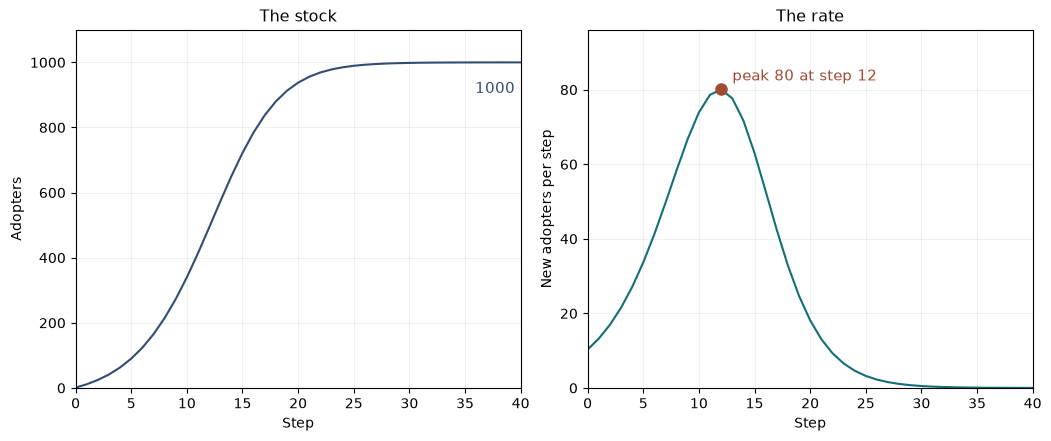

- **Adopters at step 10:** 340
- **Adopters at step 20:** 938
- **Adopters at step 40:** 1000
- **Peak adoption rate:** 80.1 at step 12

First step: rate = (0.01 + 0.30 x 1 / 1000) x (1000 - 1) = 10.29, so adopters go from 1 to 11.29. Imitation feeds on adopters while the remaining market shrinks, so the rate peaks at 80.1 in step 12 and the stock approaches 1000.

In [5]:
show(adoption_path(imitation=0.3, innovation=0.01))

**Use the idea.** Treat a growth curve as the output of two competing loops, and ask what state would make the second one bind.

**Where the conclusion applies.** One step is one period, the market is fixed at 1000 and nobody leaves. The conclusion fails if the market itself grows or adopters drop out.

*Constructed example: the chapter's model, with imitation and innovation values chosen for this reader.*

Every setting the interactive reader offers for this demonstration:

In [6]:
sweep(adoption_path, [('imitation', [0.15, 0.3, 0.45]), ('innovation', [0.01, 0.03])])

- **imitation = 0.15, innovation = 0.01**: Adopters at step 10 184; Adopters at step 20 571; Adopters at step 40 976; Peak adoption rate 42.6 at step 18
- **imitation = 0.15, innovation = 0.03**: Adopters at step 10 443; Adopters at step 20 860; Adopters at step 40 997; Peak adoption rate 54.0 at step 9
- **imitation = 0.3, innovation = 0.01**: Adopters at step 10 340; Adopters at step 20 938; Adopters at step 40 1000; Peak adoption rate 80.1 at step 12
- **imitation = 0.3, innovation = 0.03**: Adopters at step 10 671; Adopters at step 20 990; Adopters at step 40 1000; Peak adoption rate 90.2 at step 7
- **imitation = 0.45, innovation = 0.01**: Adopters at step 10 564; Adopters at step 20 998; Adopters at step 40 1000; Peak adoption rate 116.8 at step 9
- **imitation = 0.45, innovation = 0.03**: Adopters at step 10 868; Adopters at step 20 1000; Adopters at step 40 1000; Peak adoption rate 127.3 at step 6

## 2. Knockout at one state

*At a given number of adopters, which loop changes the rate more when it is cut?*

Cutting by freezing the variable the loop reads keeps the rest of the model intact. Early the remaining market is nearly full, so contact matters; later the adopters are many and the market is nearly spent, so saturation matters.

    model.adoption_rate(500.0, contact_from=0.0)
    model.adoption_rate(500.0, potential_from=0.0)

**Symbols and inputs.** contact_from freezes the adopter pool the imitation term sees; potential_from freezes the remaining market. A loop's contribution is the absolute difference between the full rate and the rate with that loop cut.

**Predict first.** At 100 adopters with imitation 0.30, which loop contributes more?

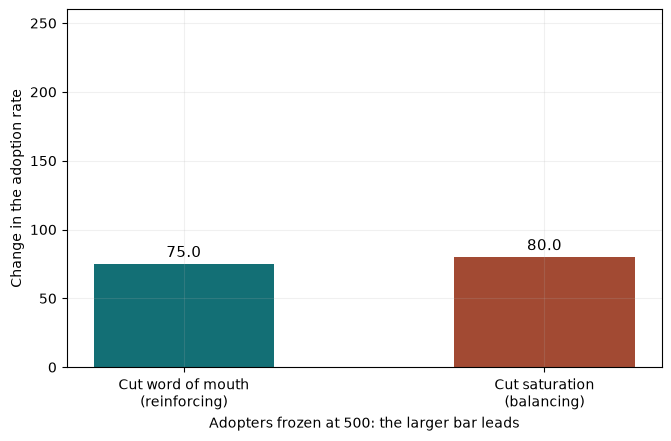

- **Rate, both loops live:** 80.0
- **Rate, word of mouth cut:** 5.0
- **Rate, saturation cut:** 160.0
- **Contribution of word of mouth:** 75.0
- **Contribution of saturation:** 80.0
- **Leading loop:** saturation

Full rate = (0.01 + 0.30 x 500 / 1000) x (1000 - 500) = 80.0. Cutting word of mouth: 0.01 x 500 = 5.0, so it contributes 80.0 - 5.0 = 75.0. Cutting saturation: (0.01 + 0.15) x 1000 = 160.0, so it contributes 160.0 - 80.0 = 80.0. The larger contribution is saturation.

In [7]:
show(knockout_rates(adopters=500.0, imitation=0.3))

**Use the idea.** Ask which loop leads at the state the organization is in today, not which loop the structure contains.

**Where the conclusion applies.** One state at a time, a market of 1000 and innovation 0.01. A tie is reported as the reinforcing loop by the chapter's rule, and with more loops the contributions would not add up.

*Constructed example: the chapter's knockout calls at several states chosen for this reader.*

Every setting the interactive reader offers for this demonstration:

In [8]:
sweep(knockout_rates, [('adopters', [100.0, 300.0, 500.0, 800.0]), ('imitation', [0.15, 0.3])])

- **adopters = 100.0, imitation = 0.15**: Rate, both loops live 22.5; Rate, word of mouth cut 9.0; Rate, saturation cut 25.0; Contribution of word of mouth 13.5; Contribution of saturation 2.5; Leading loop word of mouth
- **adopters = 100.0, imitation = 0.3**: Rate, both loops live 36.0; Rate, word of mouth cut 9.0; Rate, saturation cut 40.0; Contribution of word of mouth 27.0; Contribution of saturation 4.0; Leading loop word of mouth
- **adopters = 300.0, imitation = 0.15**: Rate, both loops live 38.5; Rate, word of mouth cut 7.0; Rate, saturation cut 55.0; Contribution of word of mouth 31.5; Contribution of saturation 16.5; Leading loop word of mouth
- **adopters = 300.0, imitation = 0.3**: Rate, both loops live 70.0; Rate, word of mouth cut 7.0; Rate, saturation cut 100.0; Contribution of word of mouth 63.0; Contribution of saturation 30.0; Leading loop word of mouth
- **adopters = 500.0, imitation = 0.15**: Rate, both loops live 42.5; Rate, word of mouth cut 5.0; Rate, saturation cut 85.0; Contribution of word of mouth 37.5; Contribution of saturation 42.5; Leading loop saturation
- **adopters = 500.0, imitation = 0.3**: Rate, both loops live 80.0; Rate, word of mouth cut 5.0; Rate, saturation cut 160.0; Contribution of word of mouth 75.0; Contribution of saturation 80.0; Leading loop saturation
- **adopters = 800.0, imitation = 0.15**: Rate, both loops live 26.0; Rate, word of mouth cut 2.0; Rate, saturation cut 130.0; Contribution of word of mouth 24.0; Contribution of saturation 104.0; Leading loop saturation
- **adopters = 800.0, imitation = 0.3**: Rate, both loops live 50.0; Rate, word of mouth cut 2.0; Rate, saturation cut 250.0; Contribution of word of mouth 48.0; Contribution of saturation 200.0; Leading loop saturation

## 3. The handover

*At which step does dominance change hands, and does it change within the window?*

Nothing about the model changes at the handover. The state moves from few adopters and a full market to many adopters and a nearly empty one, and the larger contribution passes from one loop to the other.

    handover_step(model, path)

**Symbols and inputs.** Each line is a loop's knockout contribution at every step of the run. The handover is the first step at which the leading loop differs from the step before.

**Predict first.** With imitation 0.30, does dominance change hands within 10 steps?

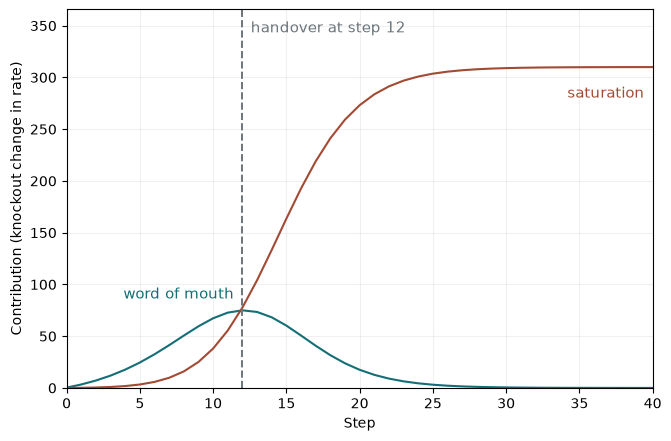

- **Handover:** step 12
- **Leader at the start:** word of mouth
- **Leader at the end:** saturation
- **Peak of word of mouth:** 75.0
- **Largest saturation:** 310.0

At step 11 the contributions are 72.8 (word of mouth) and 55.5 (saturation), so word of mouth leads. At step 12 they are 75.0 and 77.7, a difference of 77.7 - 75.0 = 2.7, so dominance passes to saturation. No parameter changed; only the state moved.

In [9]:
show(handover(imitation=0.3, steps=40))

**Use the idea.** Write the window beside every dominance claim, and report 'no handover within the window' when that is the finding.

**Where the conclusion applies.** One scenario per state of the controls, innovation 0.01 and a market of 1000. A different start or input would move the handover, so one step number is not a property of the structure.

*Constructed example: the chapter's run and handover_step, with imitation and window length varied for this reader.*

Every setting the interactive reader offers for this demonstration:

In [10]:
sweep(handover, [('imitation', [0.1, 0.3, 0.5]), ('steps', [10, 40])])

- **imitation = 0.1, steps = 10**: Handover never inside 10 steps: word of mouth leads at the start and word of mouth at the end; Leader at the start word of mouth; Leader at the end word of mouth; Peak of word of mouth 12.6; Largest saturation 3.7
- **imitation = 0.1, steps = 40**: Handover step 22; Leader at the start word of mouth; Leader at the end saturation; Peak of word of mouth 25.0; Largest saturation 86.2
- **imitation = 0.3, steps = 10**: Handover never inside 10 steps: word of mouth leads at the start and word of mouth at the end; Leader at the start word of mouth; Leader at the end word of mouth; Peak of word of mouth 67.3; Largest saturation 38.1
- **imitation = 0.3, steps = 40**: Handover step 12; Leader at the start word of mouth; Leader at the end saturation; Peak of word of mouth 75.0; Largest saturation 310.0
- **imitation = 0.5, steps = 10**: Handover step 9; Leader at the start word of mouth; Leader at the end saturation; Peak of word of mouth 124.9; Largest saturation 215.2
- **imitation = 0.5, steps = 40**: Handover step 9; Leader at the start word of mouth; Leader at the end saturation; Peak of word of mouth 124.9; Largest saturation 510.0

## 4. The same intervention in two regimes

*Does a referral incentive help as much after the handover as before it?*

Before the handover the contact term is the live constraint, so raising imitation moves the rate. After it the remaining market is the constraint, and referrals still move the rate (at step 12 they add more than a larger market does) until the market is nearly spent, when more market is what moves it.

    path = run(model, steps=40)
    handover_step(model, path)

**Symbols and inputs.** The baseline is imitation 0.30 in a market of 1000. A referral incentive raises imitation to 0.40. Expanding the market raises it to 1200. The bars are the adoption rate at the state the baseline run is in at the chosen step.

**Predict first.** At step 25, does the referral incentive or the market expansion change the adoption rate more?

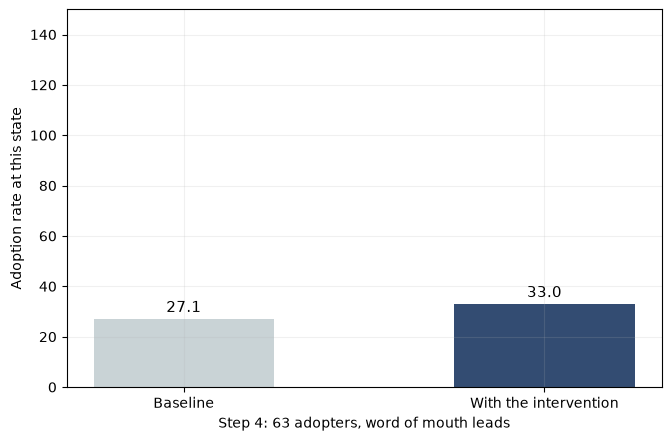

- **Adopters at this step:** 63
- **Leading loop:** word of mouth
- **Baseline rate:** 27.1
- **Rate with the intervention:** 33.0
- **Change in the rate:** 5.9

Referral incentive (imitation 0.30 to 0.40) at step 4. With imitation 0.40: (0.01 + 0.40 x 63 / 1000) x (1000 - 63) = 33.0, against 27.1. The change is 33.0 - 27.1 = 5.9 new adopters per step at this state, while word of mouth leads. This compares rates at one state, not final outcomes.

In [11]:
show(intervention_by_regime(step=4, intervention='referral'))

**Use the idea.** Pair every intervention with the regime it acts in, and list what to do now separately from what to prepare.

**Where the conclusion applies.** A rate comparison at one state, with the baseline path held fixed. It says nothing about the cost of either intervention or the path the system would then follow.

*Constructed example: the chapter's model with two interventions defined for this reader.*

Every setting the interactive reader offers for this demonstration:

In [12]:
sweep(intervention_by_regime, [('step', [4, 12, 25]), ('intervention', ['referral', 'market'])])

- **step = 4, intervention = referral**: Adopters at this step 63; Leading loop word of mouth; Baseline rate 27.1; Rate with the intervention 33.0; Change in the rate 5.9
- **step = 4, intervention = market**: Adopters at this step 63; Leading loop word of mouth; Baseline rate 27.1; Rate with the intervention 29.3; Change in the rate 2.2
- **step = 12, intervention = referral**: Adopters at this step 492; Leading loop saturation; Baseline rate 80.1; Rate with the intervention 105.1; Change in the rate 25.0
- **step = 12, intervention = market**: Adopters at this step 492; Leading loop saturation; Baseline rate 80.1; Rate with the intervention 94.2; Change in the rate 14.1
- **step = 25, intervention = referral**: Adopters at this step 989; Leading loop saturation; Baseline rate 3.2; Rate with the intervention 4.3; Change in the rate 1.0
- **step = 25, intervention = market**: Adopters at this step 989; Leading loop saturation; Baseline rate 3.2; Rate with the intervention 54.2; Change in the rate 51.0

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

With imitation 0.30 and innovation 0.01, what is the first-step rate from 1 adopter?

<details><summary>Answer</summary>

(0.01 + 0.30 x 1 / 1000) x (1000 - 1) = 0.0103 x 999 = 10.29, so adopters rise to 11.29.

</details>

### Exercise 2

At 500 adopters with imitation 0.30, what is the contribution of word of mouth?

<details><summary>Answer</summary>

Full rate (0.01 + 0.30 x 500 / 1000) x 500 = 80.0; with contact cut 0.01 x 500 = 5.0; so 80.0 - 5.0 = 75.0.

</details>

### Exercise 3

With imitation 0.30 over 40 steps, at which step does dominance change hands?

<details><summary>Answer</summary>

At step 12: word of mouth contributes about 75 and saturation about 78, so saturation takes over, as the chapter reports.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/